In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.svm import SVR
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# Set plot style for clean visuals
sns.set_theme(style="whitegrid")

# 1. Load the California Housing dataset
california = fetch_california_housing(as_frame=True)
df = california.frame

# Rename target column to MedianHouseValue for clarity (Target is in units of $100,000)
df = df.rename(columns={'MedHouseVal': 'MedianHouseValue'})

print("--- Dataset Snapshot ---")
print(f"Dataset Dimensions: {df.shape[0]} rows, {df.shape[1]} columns")
print("\n--- Missing Values Check ---")
print(df.isnull().sum())

# 2. Separate Features (X) and Target (y)
X = df.drop(columns=['MedianHouseValue'])
y = df['MedianHouseValue']

# 3. Train-Test Split (80% Train, 20% Test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 4. Feature Scaling (Standardization)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("\nPreprocessing Completed successfully.")

--- Dataset Snapshot ---
Dataset Dimensions: 20640 rows, 9 columns

--- Missing Values Check ---
MedInc              0
HouseAge            0
AveRooms            0
AveBedrms           0
Population          0
AveOccup            0
Latitude            0
Longitude           0
MedianHouseValue    0
dtype: int64

Preprocessing Completed successfully.


In [2]:
# Initialize dictionaries to store trained models and evaluation metrics
models = {
    "Linear Regression": LinearRegression(),
    "Decision Tree": DecisionTreeRegressor(random_state=42, max_depth=10),
    "Random Forest": RandomForestRegressor(random_state=42, n_estimators=100, max_depth=15, n_jobs=-1),
    "Gradient Boosting": GradientBoostingRegressor(random_state=42, n_estimators=100, learning_rate=0.1),
    "Support Vector Regressor (SVR)": SVR(kernel='rbf', C=1.0, epsilon=0.1)
}

results = {}

print("--- Training Models ---")
for name, model in models.items():
    print(f"Training {name}...")
    # SVR and Linear Regression perform optimally on scaled features
    model.fit(X_train_scaled, y_train)
    
    # Predict on test data
    y_pred = model.predict(X_test_scaled)
    
    # Calculate performance metrics
    mse = mean_squared_error(y_test, y_pred)
    mae = mean_absolute_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)
    
    # Save the evaluations
    results[name] = {"MSE": mse, "MAE": mae, "R2 Score": r2}

print("\nAll models trained and evaluated successfully.")

--- Training Models ---
Training Linear Regression...
Training Decision Tree...
Training Random Forest...
Training Gradient Boosting...
Training Support Vector Regressor (SVR)...

All models trained and evaluated successfully.


--- Model Performance Comparison Table ---
                                   MSE     MAE  R2 Score
Linear Regression               0.5559  0.5332    0.5758
Decision Tree                   0.4150  0.4330    0.6833
Random Forest                   0.2611  0.3329    0.8008
Gradient Boosting               0.2940  0.3717    0.7756
Support Vector Regressor (SVR)  0.3570  0.3986    0.7276


/var/folders/1q/jh6vz5fs60gf8h_62r11lky00000gn/T/ipykernel_48149/1480347490.py:13: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[0].set_xticklabels(results_df.index, rotation=30, ha='right')
/var/folders/1q/jh6vz5fs60gf8h_62r11lky00000gn/T/ipykernel_48149/1480347490.py:19: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[1].set_xticklabels(results_df.index, rotation=30, ha='right')


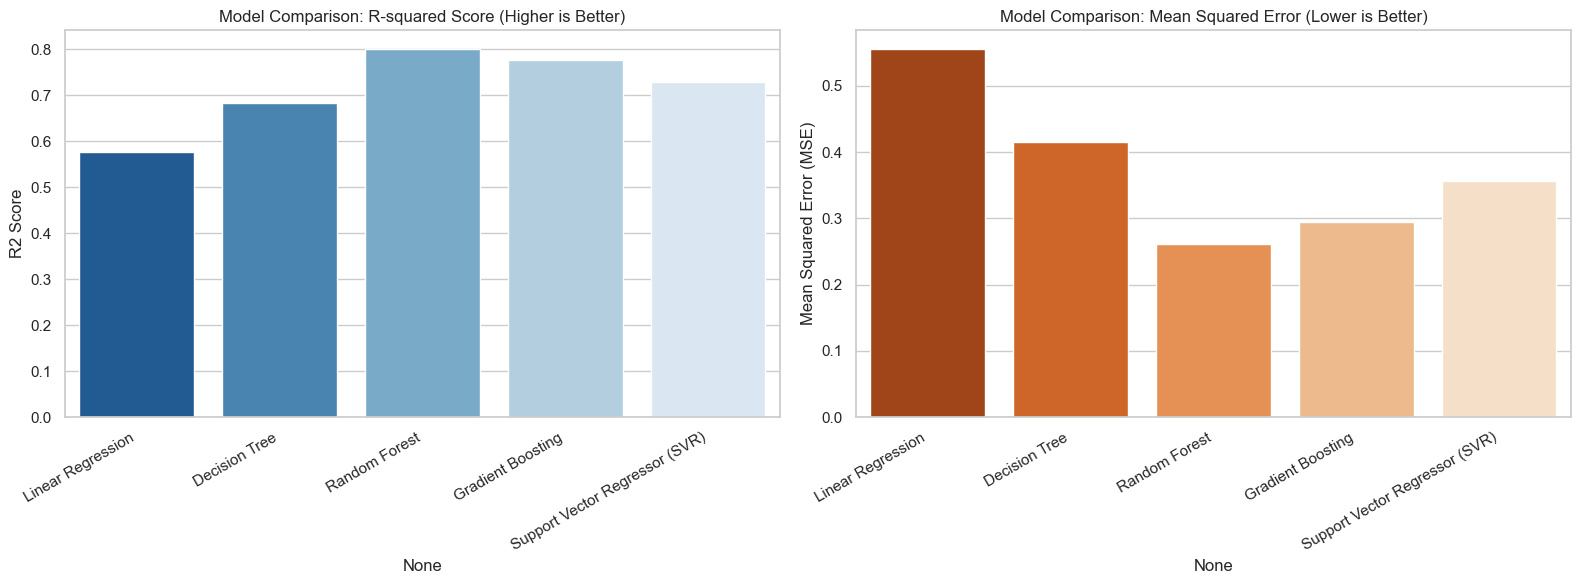

In [3]:
# Convert evaluations dictionary into a DataFrame for visual reporting
results_df = pd.DataFrame(results).T
print("--- Model Performance Comparison Table ---")
print(results_df.round(4))

# Visualization: Compare R-squared and Mean Squared Error across models
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Plot R2 Scores
sns.barplot(x=results_df.index, y=results_df['R2 Score'], ax=axes[0], palette='Blues_r', hue=results_df.index, legend=False)
axes[0].set_title('Model Comparison: R-squared Score (Higher is Better)')
axes[0].set_ylabel('R2 Score')
axes[0].set_xticklabels(results_df.index, rotation=30, ha='right')

# Plot MSE Scores
sns.barplot(x=results_df.index, y=results_df['MSE'], ax=axes[1], palette='Oranges_r', hue=results_df.index, legend=False)
axes[1].set_title('Model Comparison: Mean Squared Error (Lower is Better)')
axes[1].set_ylabel('Mean Squared Error (MSE)')
axes[1].set_xticklabels(results_df.index, rotation=30, ha='right')

plt.tight_layout()
plt.show()